#  Analyse Exploratoire des Accidents de la Route aux États-Unis (EDA)

## Objectifs
Cette phase vise à :
- Comprendre la structure globale des accidents de la route
- Identifier des tendances temporelles et géographiques
- Explorer les relations entre la gravité des accidents, le temps, la météo et les infrastructures routières
- Préparer le terrain pour les analyses statistiques avancées

Les données ont été préalablement nettoyées et imputées afin de garantir la fiabilité des analyses.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [9]:
df= pd.read_csv("us_cleaned.csv")

In [10]:
df.shape


(500000, 43)

In [11]:
df.head()

,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,I-70 E,...,False,False,False,False,False,False,Night,Night,Night,Night
1,1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Brice Rd,...,False,False,False,False,False,False,Night,Night,Night,Day
2,2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,State Route 32,...,False,False,False,False,True,False,Night,Night,Day,Day
3,3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,I-75 S,...,False,False,False,False,False,False,Night,Day,Day,Day
4,4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Miamisburg Centerville Rd,...,False,False,False,False,True,False,Day,Day,Day,Day


In [12]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,500000.0,NaN,NaN,NaN,249999.5,144337.711635,0.0,124999.75,249999.5,374999.25,499999.0
ID,500000,500000,A-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,500000,2,Source2,495498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Severity,500000.0,NaN,NaN,NaN,2.37469,0.486796,1.0,2.0,2.0,3.0,4.0
Start_Time,500000,492500,2016-04-10 08:59:26,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Time,500000,488976,2016-10-14 19:50:00,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_Lat,500000.0,NaN,NaN,NaN,35.929426,5.032482,25.433098,32.811352,34.24725,40.134354,48.19997
Start_Lng,500000.0,NaN,NaN,NaN,-97.590381,18.280944,-123.813927,-118.096634,-95.543968,-81.56575,-70.571518
Distance(mi),500000.0,NaN,NaN,NaN,0.065294,0.782881,0.0,0.0,0.01,0.01,90.370003
Street,500000,45167,I-5 N,6487,NaN,NaN,NaN,NaN,NaN,NaN,NaN


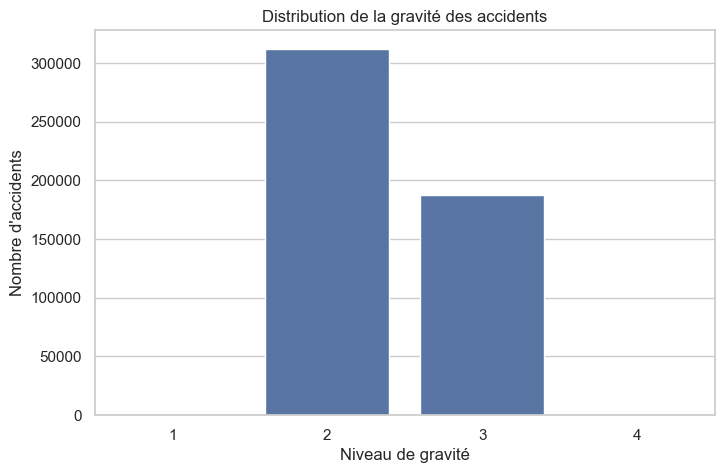

In [13]:
severity_counts = df['Severity'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=severity_counts.index, y=severity_counts.values)
plt.title("Distribution de la gravité des accidents")
plt.xlabel("Niveau de gravité")
plt.ylabel("Nombre d'accidents")
plt.show()


In [14]:
df['Year'] = df['Start_Time'].dt.year

accidents_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
accidents_year.plot(kind='line', marker='o')
plt.title("Évolution annuelle des accidents")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.show()


AttributeError: Can only use .dt accessor with datetimelike values